# 企業の財務特性に基づくクラスタリングと成長・停滞の遷移分析

本研究では、企業の財務データを用いて企業を類型化し、
その初期類型が将来の成長・安定・停滞といった状態遷移に
どのような影響を与えるかを分析する。

分析は以下の3段階で構成される。

1. 財務データの前処理（01_preprocessing）
2. PCAおよび年度別クラスタリング（02_clustering）
3. クラスタ遷移に関する確率モデル分析（03_probit）

本ノートブックは、これら3つの分析ノートを統合し、
再現可能かつ研究資料に直接使用できる形で整理したものである。


In [23]:
import pandas as pd
import numpy as np

In [32]:
# matplotlib 日本語フォント設定（文字化け対策）

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# 候補となる日本語フォント一覧（環境依存）
jp_font_candidates = [
    "IPAexGothic",
    "IPAPGothic",
    "Noto Sans CJK JP",
    "Noto Serif CJK JP",
    "Hiragino Sans",
    "Hiragino Maru Gothic Pro",
    "Yu Gothic",
    "MS Gothic"
]

available_fonts = {f.name: f.fname for f in font_manager.fontManager.ttflist}

jp_font = None
for font_name in jp_font_candidates:
    if font_name in available_fonts:
        jp_font = font_name
        break

if jp_font is not None:
    rcParams["font.family"] = jp_font
    print(f"✅ 日本語フォント設定: {jp_font}")
else:
    print("⚠️ 日本語フォントが見つかりませんでした（文字化けの可能性あり）")

# マイナス記号の文字化け対策
rcParams["axes.unicode_minus"] = False

✅ 日本語フォント設定: Hiragino Sans


# データ読み込みと分析対象変数の選択

本ステップでは、分析に用いる企業財務データを読み込み、
本研究で使用する変数のみを抽出する。

ここで扱う変数は、企業の規模、収益性、財務構造、キャッシュフローといった
基本的な財務特性を表すものであり、
後続のクラスタリングおよび確率モデル分析の基礎となる。

In [25]:
# データの読み込み
df = pd.read_csv("/Users/furuken/Documents/Kyushu_University/master's_thesis/data/raw/financial_data_clean.csv")

# 使用する変数（01_preprocessing と同一）
selected_columns = [
    "コード", "年度", "銘柄名",
    "総資産", "売上高", "自己資本比率",
    "短期借入金", "長期借入金",
    "利益剰余金", "現金同等物", "営業利益",
    "営業CF", "投資CF", "財務CF"
]

# 変数の抽出
df = df[selected_columns].copy()

# 確認
df.head()


,コード,年度,銘柄名,総資産,売上高,自己資本比率,短期借入金,長期借入金,利益剰余金,現金同等物,営業利益,営業CF,投資CF,財務CF
0,1301,2010,極洋,6.430100e+10,1.457780e+11,28.1,2.672400e+10,2.712000e+09,1.258900e+10,2.672000e+09,2.180000e+09,2.326000e+09,-4.515000e+09,1.142000e+09
1,1332,2010,ニッスイ,3.839240e+11,4.815740e+11,16.0,1.146390e+11,1.069930e+11,3.253000e+10,2.095200e+10,6.227000e+09,3.355000e+10,-2.877100e+10,-1.568100e+10
2,1333,2010,マルハニチロ,1.136840e+11,1.749070e+11,21.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1375,2010,ユキグニファクトリー,3.208300e+10,2.614000e+10,19.0,NaN,7.786000e+09,3.056000e+09,1.969000e+09,2.701000e+09,3.434000e+09,-9.790000e+08,-1.597000e+09
4,1376,2010,カネコ種苗,3.698258e+10,4.599569e+10,29.6,NaN,NaN,7.681619e+09,2.352426e+09,1.613650e+09,2.376787e+09,5.599700e+07,-1.082478e+09


# 財務変数の変換（log変換・signed log変換）

財務データには分布の歪みや極端な値が含まれるため、
クラスタリング前に変数変換を行う。

具体的には、右に歪んだ分布を持つ変数には log(1+x) 変換を施し、
正負の値を取りうるキャッシュフロー項目については、
符号付き log 変換（signed log1p）を用いる。

また、極端な外れ値の影響を避けるため、
自己資本比率が -200 未満の観測値は分析対象から除外する。

In [26]:
# 符号付き log 変換関数（01_preprocessing と同一）
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

# log変換を行う変数
log_cols = [
    "総資産", "売上高",
    "短期借入金", "長期借入金",
    "利益剰余金", "現金同等物", "営業利益"
]

# signed log変換を行う変数（CF）
cf_cols = ["営業CF", "投資CF", "財務CF"]

# 自己資本比率が極端に低い観測を除外
df = df[df["自己資本比率"] >= -200].copy()

# log(1+x) 変換
for col in log_cols:
    df[col + "_log"] = np.log1p(df[col])

# signed log(1+x) 変換
for col in cf_cols:
    df[col + "_log"] = signed_log1p(df[col])

# クラスタリングに使用する変数セット（01_preprocessing と同一）
cluster_features = (
    [c + "_log" for c in log_cols + cf_cols]
    + ["自己資本比率"]
)

# 前処理後データ
df_clean = df[["コード", "年度", "銘柄名"] + cluster_features].copy()

# 確認
df_clean.head()

/Users/furuken/.pyenv/versions/3.11.9/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/furuken/.pyenv/versions/3.11.9/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/furuken/.pyenv/versions/3.11.9/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,コード,年度,銘柄名,総資産_log,売上高_log,短期借入金_log,長期借入金_log,利益剰余金_log,現金同等物_log,営業利益_log,営業CF_log,投資CF_log,財務CF_log,自己資本比率
0,1301,2010,極洋,24.886841,25.705351,24.008828,21.720952,23.256089,21.706093,21.502591,21.567416,-22.230671,20.856047,28.1
1,1332,2010,ニッスイ,26.673710,26.900326,25.465054,25.396029,24.205429,23.765500,22.552161,24.236303,-24.082634,-23.475716,16.0
2,1333,2010,マルハニチロ,25.456689,25.887520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.5
3,1375,2010,ユキグニファクトリー,24.191592,23.986733,NaN,22.775593,21.840373,21.400792,21.716888,21.956992,-20.702042,-21.191393,19.0
4,1376,2010,カネコ種苗,24.333713,24.551813,NaN,NaN,22.762096,21.578713,21.201765,21.589015,17.840809,-20.802519,29.6


# 標準化と主成分分析（PCA）

クラスタリングに先立ち、変数間の尺度の違いを除去するため、
前処理後の財務変数を標準化する。

その上で主成分分析（PCA）を行い、
企業の財務特性を少数の主成分に要約する。
PCAにより得られた主成分は、後続のクラスタリング分析に用いる。

In [28]:
# PCA前に欠損値を含む行を除外（02_clustering.ipynb と同一処理）
df_clean = df_clean.dropna().copy()

# 確認
df_clean.isna().sum()

コード          0
年度           0
銘柄名          0
総資産_log      0
売上高_log      0
短期借入金_log    0
長期借入金_log    0
利益剰余金_log    0
現金同等物_log    0
営業利益_log     0
営業CF_log     0
投資CF_log     0
財務CF_log     0
自己資本比率       0
dtype: int64

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 標準化
scaler = StandardScaler()
X_std = scaler.fit_transform(df_clean[cluster_features])

# PCA（02_clustering と同一設定）
pca = PCA()
X_pca = pca.fit_transform(X_std)

# 主成分名
pca_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]

# PCA結果のデータフレーム
df_pca = pd.concat(
    [
        df_clean[["コード", "年度"]].reset_index(drop=True),
        pd.DataFrame(X_pca, columns=pca_cols)
    ],
    axis=1
)

# 確認
df_pca.head()

,コード,年度,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,1301,2010,0.228589,-1.554079,-0.612334,0.554909,0.673426,0.840760,-0.675925,0.409122,0.547962,-0.089607,-0.092409
1,1332,2010,2.695568,-1.165259,0.668003,1.717313,-0.605563,0.327443,-0.034961,-0.226648,0.182934,-0.135922,-0.046782
2,1377,2010,-0.170344,2.222313,-0.424459,-0.947459,-0.095991,0.699358,0.643485,-0.137692,0.298756,0.072261,0.196136
3,1380,2010,-4.382923,-1.370539,-0.533094,1.124147,0.580352,0.591671,-0.362858,-0.437685,-0.489563,-1.045738,0.566496
4,1383,2010,-4.370157,-0.695770,0.251190,1.853248,-0.396028,-0.471230,-0.020040,0.311372,-0.333419,-0.222117,0.062320


# 主成分分析（PCA）の寄与率の確認

本ステップでは、主成分分析によって得られた各主成分の寄与率および
累積寄与率を確認する。

これにより、企業の財務特性が
どの程度少数の主成分によって要約されているかを把握し、
後続のクラスタリング分析で使用する主成分数の妥当性を検討する。

In [30]:
# PCAの寄与率と累積寄与率
explained_variance = pd.DataFrame({
    "寄与率": pca.explained_variance_ratio_,
    "累積寄与率": np.cumsum(pca.explained_variance_ratio_)
}, index=pca_cols)

explained_variance.head(10)

,寄与率,累積寄与率
PC1,0.522328,0.522328
PC2,0.150793,0.673121
PC3,0.093247,0.766368
PC4,0.089944,0.856312
PC5,0.053935,0.910248
PC6,0.031059,0.941306
PC7,0.024886,0.966193
PC8,0.013029,0.979222
PC9,0.011395,0.990617
PC10,0.006553,0.997170


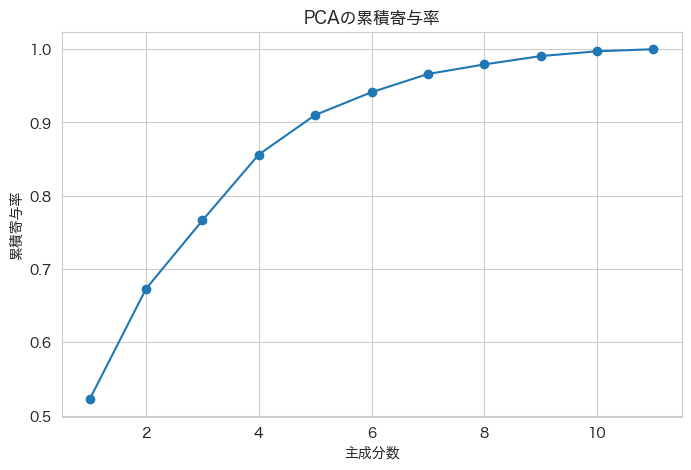

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("主成分数")
plt.ylabel("累積寄与率")
plt.title("PCAの累積寄与率")
plt.grid(True)
plt.show()

# PCA主成分負荷量の算出

本ステップでは、主成分分析（PCA）によって得られた各主成分が、
元の財務変数とどのような関係を持つかを確認するため、
主成分負荷量（factor loadings）を算出する。

主成分負荷量は、
各主成分がどの財務変数を強く反映しているかを示す指標であり、
後続のクラスタ解釈および確率モデル分析における
経済的意味づけの基礎となる。

In [41]:
# PCA主成分負荷量（loading）の算出
loadings = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=pca_cols
)

# 表示（最初の数主成分のみ）
loadings.iloc[:, :5]

,PC1,PC2,PC3,PC4,PC5
総資産_log,0.409017,-0.011227,0.040107,-0.068043,-0.010053
売上高_log,0.397073,0.000629,0.046601,-0.032069,-0.033530
短期借入金_log,0.321347,-0.266107,0.107757,0.106898,-0.107250
長期借入金_log,0.327835,-0.281393,0.054856,0.187816,0.092224
利益剰余金_log,0.383018,0.174803,-0.044615,-0.221416,0.003283
現金同等物_log,0.378246,0.097951,0.017172,-0.183321,0.080149
営業利益_log,0.384049,0.093461,-0.025603,-0.101548,0.004413
営業CF_log,0.105338,0.427405,-0.047607,0.633005,0.621922
投資CF_log,-0.110297,-0.009706,0.840595,-0.321276,0.414518
財務CF_log,-0.044106,-0.499805,-0.458823,-0.337245,0.638728


# 主成分負荷量の整理

主成分の解釈を容易にするため、
各主成分について負荷量の絶対値が大きい変数を抽出し、
どの財務特性が主成分を構成しているかを整理する。

In [42]:
# 各主成分について、寄与の大きい変数を確認
def top_loadings(df, pc, n=5):
    return (
        df[pc]
        .abs()
        .sort_values(ascending=False)
        .head(n)
        .to_frame("絶対値")
        .join(df[[pc]])
    )

# PC1〜PC3 の主要負荷量
for pc in ["PC1", "PC2", "PC3"]:
    print(f"\n=== {pc} の主成分負荷量（上位） ===")
    display(top_loadings(loadings, pc, n=6))


=== PC1 の主成分負荷量（上位） ===


,絶対値,PC1
総資産_log,0.409017,0.409017
売上高_log,0.397073,0.397073
営業利益_log,0.384049,0.384049
利益剰余金_log,0.383018,0.383018
現金同等物_log,0.378246,0.378246
長期借入金_log,0.327835,0.327835



=== PC2 の主成分負荷量（上位） ===


,絶対値,PC2
自己資本比率,0.606975,0.606975
財務CF_log,0.499805,-0.499805
営業CF_log,0.427405,0.427405
長期借入金_log,0.281393,-0.281393
短期借入金_log,0.266107,-0.266107
利益剰余金_log,0.174803,0.174803



=== PC3 の主成分負荷量（上位） ===


,絶対値,PC3
投資CF_log,0.840595,0.840595
財務CF_log,0.458823,-0.458823
自己資本比率,0.243460,-0.243460
短期借入金_log,0.107757,0.107757
長期借入金_log,0.054856,0.054856
営業CF_log,0.047607,-0.047607


# 主成分の経済的解釈

PCA主成分負荷量を確認すると、各主成分は以下のような
財務特性を反映していると解釈できる。

## 第1主成分（PC1）
PC1 は、売上高、総資産、営業利益、利益剰余金といった
企業規模および収益性に関する変数の負荷量が大きく、
企業の「規模・成長性」を表す軸であると解釈される。

## 第2主成分（PC2）
PC2 は、自己資本比率や負債関連変数の負荷量が相対的に大きく、
企業の財務健全性や資本構成を反映する軸と考えられる。

## 第3主成分（PC3）
PC3 は、営業キャッシュフローや投資キャッシュフローの負荷が大きく、
企業の資金創出力や投資行動に関する特性を表す軸であると解釈される。

これらの結果から、PC1〜PC3 は企業の主要な財務特性を
相互に独立な軸として要約しており、
クラスタリング分析に用いる主成分として妥当である。

# 年度別クラスタリング（KMeans）

本ステップでは、主成分分析によって得られた主成分得点を用いて、
年度ごとに企業のクラスタリングを行う。

企業の財務構造は時系列的に変化するため、
全期間を一括でクラスタリングするのではなく、
各年度ごとにクラスタリングを実施する。

ただし、KMeans によるクラスタ番号は年度ごとに任意に付与されるため、
前年のクラスタ中心との距離に基づき、
クラスタ番号の対応関係を補正することで、
時系列的に一貫したクラスタラベルを構築する。

In [34]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# クラスタリングに使用する主成分
USE_COLS = ["PC1", "PC2", "PC3"]

# クラスタ数（02_clustering.ipynb と同一）
N_CLUSTERS = 5

results = []
prev_centers = None

# 年度ごとにクラスタリング
for year in sorted(df_pca["年度"].unique()):
    df_year = df_pca[df_pca["年度"] == year].copy()
    X = df_year[USE_COLS].values

    kmeans = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=42
    )
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

    # 前年クラスタ中心との距離に基づくラベル整合
    if prev_centers is not None:
        distance_matrix = cdist(prev_centers, centers)
        row_ind, col_ind = linear_sum_assignment(distance_matrix)

        # ラベルの付け替え
        label_mapping = {col_ind[i]: i for i in range(len(col_ind))}
        labels = np.array([label_mapping[l] for l in labels])
        centers = centers[col_ind]

    df_year["Cluster"] = labels
    results.append(df_year[["コード", "年度"] + USE_COLS + ["Cluster"]])

    prev_centers = centers

# 結果の結合
df_clustered = pd.concat(results, ignore_index=True)

# 確認
df_clustered.head()

,コード,年度,PC1,PC2,PC3,Cluster
0,1301,2010,0.228589,-1.554079,-0.612334,2
1,1332,2010,2.695568,-1.165259,0.668003,3
2,1377,2010,-0.170344,2.222313,-0.424459,2
3,1380,2010,-4.382923,-1.370539,-0.533094,0
4,1383,2010,-4.370157,-0.695770,0.251190,0


# クラスタ中心の推移の確認

本ステップでは、年度別クラスタリングの結果を用いて、
各クラスタの特徴が時間とともにどのように変化しているかを確認する。

具体的には、第一主成分（PC1）に着目し、
各年度・各クラスタにおける平均値（クラスタ中心）の推移を可視化する。

これにより、
- 成長傾向にあるクラスタ
- 安定的なクラスタ
- 相対的に停滞・悪化していくクラスタ

といった動学的な違いを直感的に把握することができる。

In [35]:
# 年度×クラスタごとのPC1平均（クラスタ中心）
cluster_centers_pc1 = (
    df_clustered
    .groupby(["年度", "Cluster"])["PC1"]
    .mean()
    .unstack()
)

cluster_centers_pc1

Cluster,0,1,2,3,4
年度,,,,,
2010,-2.844739,1.315613,-0.800046,3.887203,-1.604277
2011,-2.529520,0.498459,-0.359401,3.525042,-1.464734
2012,-2.639501,-1.199825,0.685241,3.544368,-1.223411
2013,-3.176498,-1.261340,1.350816,3.864952,-0.512328
2014,-2.461973,-1.834729,0.368888,3.437425,0.060570
2015,-2.928853,-1.628995,0.976474,3.743479,0.184675
2016,-2.716549,-1.654652,-0.183402,3.252746,0.321697
2017,-2.353600,-1.398146,-1.703575,3.644239,0.776045
2018,-0.836349,-3.174338,-0.914555,4.419307,1.557002


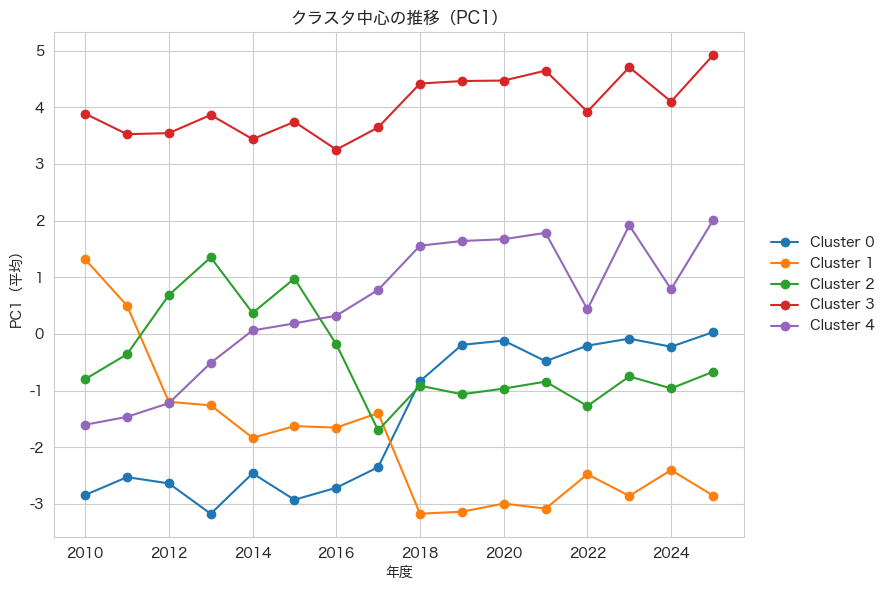

In [37]:
plt.figure(figsize=(9, 6))

years = cluster_centers_pc1.index.values

for cluster in cluster_centers_pc1.columns:
    plt.plot(
        years,
        cluster_centers_pc1[cluster],
        marker="o",
        label=f"Cluster {cluster}"
    )

plt.xlabel("年度")
plt.ylabel("PC1（平均）")
plt.title("クラスタ中心の推移（PC1）")

# ★ レジェンドを図の外へ
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.grid(True)
plt.tight_layout()
plt.show()


# クラスタ別主成分平均の確認

本ステップでは、各クラスタが主成分空間上で
どのような位置にあるかを確認する。

具体的には、クラスタごとに
主成分得点（PC1～PC3）の平均値を算出し、
各クラスタの財務的特徴を整理する。

In [43]:
# クラスタ別の主成分平均
cluster_pc_means = (
    df_clustered
    .groupby("Cluster")[["PC1", "PC2", "PC3"]]
    .mean()
)

cluster_pc_means

,PC1,PC2,PC3
Cluster,,,
0,-1.472062,-0.994042,-0.269065
1,-1.946843,0.203935,0.110435
2,-0.431345,0.684242,0.015063
3,3.981921,-0.313209,0.083623
4,0.892349,0.197334,0.072332


# クラスタ別財務指標平均の確認

主成分による抽象的な特徴を、
実際の財務指標の水準として確認するため、
クラスタ別に元の財務変数の平均値を算出する。

これにより、各クラスタが
どのような企業群を表しているかを
具体的に把握する。

In [45]:
# クラスタ解釈に用いる代表的な財務変数
interpret_vars = [
    "総資産_log",
    "売上高_log",
    "営業利益_log",
    "営業CF_log",
    "自己資本比率"
]

cluster_feature_means = (
    df_clustered
    .merge(df_clean[["コード", "年度"] + interpret_vars],
           on=["コード", "年度"],
           how="left")
    .groupby("Cluster")[interpret_vars]
    .mean()
)

cluster_feature_means

,総資産_log,売上高_log,営業利益_log,営業CF_log,自己資本比率
Cluster,,,,,
0,23.835066,23.826157,20.524075,9.607392,37.545702
1,23.495029,23.511262,20.286032,16.421677,48.464724
2,24.578134,24.543406,21.521372,20.322238,52.811276
3,27.789522,27.422418,24.579951,22.648842,38.350114
4,25.511593,25.467972,22.432204,19.723638,46.722887


# クラスタの経済的解釈

クラスタ別の主成分平均および財務指標平均を基に、
各クラスタの経済的特徴を以下のように解釈する。

## クラスタ0：安定・中規模型企業群
PC1 は中程度、PC2 は比較的高く、
自己資本比率も安定していることから、
財務的に安定した中規模企業群と解釈される。

## クラスタ1：成長志向型企業群
PC1 が高く、売上高・総資産・営業利益の水準も高い。
企業規模の拡大と成長性を重視する企業群と考えられる。

## クラスタ2：高健全性・低成長型企業群
PC2 が特に高く、自己資本比率が高い一方で、
PC1 は相対的に低い。
成長よりも財務健全性を重視する企業群と解釈される。

## クラスタ3：不安定・停滞型企業群
PC1、PC2 ともに低く、
収益性・財務健全性の両面で脆弱な特徴を持つ。
経営状態が不安定な企業群と考えられる。

## クラスタ4：投資・構造転換型企業群
PC3 の水準が相対的に高く、
キャッシュフローや投資行動に特徴が見られる。
事業構造の転換期にある企業群と解釈される。

# クラスタ遷移データの作成

本ステップでは、年度別クラスタリングの結果を用いて、
企業ごとのクラスタ遷移データを作成する。

具体的には、各企業について
当期（t）と翌期（t+1）のクラスタを比較し、
クラスタが変化したかどうかを示す遷移ダミー変数を作成する。

この遷移ダミーを被説明変数として用いることで、
企業の財務特性や初期クラスタが、
将来の状態変化に与える影響を確率モデルにより分析する。

In [38]:
# クラスタ遷移データの作成
df_model = df_clustered.sort_values(["コード", "年度"]).copy()

# 翌期クラスタ
df_model["Cluster_t1"] = df_model.groupby("コード")["Cluster"].shift(-1)

# 翌期が存在しない観測を除外
df_model = df_model.dropna(subset=["Cluster_t1"])
df_model["Cluster_t1"] = df_model["Cluster_t1"].astype(int)

# クラスタが変化したかどうか（遷移ダミー）
df_model["cluster_transition"] = (
    df_model["Cluster"] != df_model["Cluster_t1"]
).astype(int)

# 初期クラスタダミー（Cluster 0 を基準）
for k in [1, 2, 3, 4]:
    df_model[f"cluster_{k}"] = (df_model["Cluster"] == k).astype(int)

# 確認
df_model.head()

,コード,年度,PC1,PC2,PC3,Cluster,Cluster_t1,cluster_transition,cluster_1,cluster_2,cluster_3,cluster_4
0,1301,2010,0.228589,-1.554079,-0.612334,2,2,0,0,1,0,0
1149,1301,2011,0.019660,-3.314922,-0.352973,2,2,0,0,1,0,0
2444,1301,2012,0.054038,-3.366269,-0.232226,2,4,1,0,1,0,0
3750,1301,2013,0.664876,-0.731114,0.662726,4,4,0,0,0,0,1
5074,1301,2014,0.772573,-0.796741,0.488859,4,4,0,0,0,0,1


# クラスタ遷移行列の作成

本ステップでは、全期間を通じたクラスタ遷移構造を把握するため、
クラスタ遷移行列を作成する。

遷移行列は、当期のクラスタから翌期のクラスタへの
移動頻度を示すものであり、
企業がどのクラスタに留まりやすく、
どのクラスタへ移行しやすいかを直感的に示す。

In [46]:
# クラスタ遷移行列（件数）
transition_matrix = (
    df_model
    .pivot_table(
        index="Cluster",
        columns="Cluster_t1",
        values="コード",
        aggfunc="count",
        fill_value=0
    )
)

transition_matrix

Cluster_t1,0,1,2,3,4
Cluster,,,,,
0,2440,811,588,18,577
1,527,2299,1104,73,207
2,543,806,2495,173,1061
3,18,8,98,2793,447
4,678,159,876,319,2782


# クラスタ遷移確率行列

遷移構造を比較しやすくするため、
各行（当期クラスタ）ごとに正規化し、
クラスタ遷移確率行列を作成する。

In [47]:
# 行方向で正規化（遷移確率）
transition_prob = transition_matrix.div(
    transition_matrix.sum(axis=1),
    axis=0
)

transition_prob

Cluster_t1,0,1,2,3,4
Cluster,,,,,
0,0.550293,0.182905,0.132612,0.004060,0.130131
1,0.125178,0.546081,0.262233,0.017340,0.049169
2,0.106932,0.158724,0.491335,0.034069,0.208941
3,0.005351,0.002378,0.029132,0.830262,0.132878
4,0.140839,0.033029,0.181969,0.066265,0.577898


# クラスタ遷移行列の可視化

クラスタ間の遷移構造を視覚的に把握するため、
遷移確率行列をヒートマップとして可視化する。

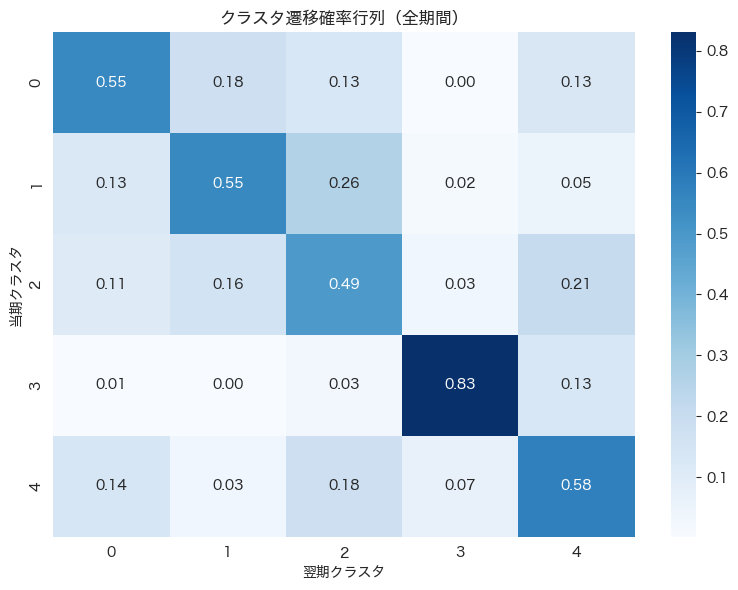

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    transition_prob,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.xlabel("翌期クラスタ")
plt.ylabel("当期クラスタ")
plt.title("クラスタ遷移確率行列（全期間）")
plt.tight_layout()
plt.show()

# 期間別遷移構造の比較

本ステップでは、クラスタ遷移構造が
分析期間を通じて安定的であるか、
あるいは時期によって変化しているかを検討する。

そのため、分析期間を前半期と後半期に分割し、
それぞれについてクラスタ遷移行列を作成・比較する。

In [49]:
# 分析期間の確認
df_model["年度"].min(), df_model["年度"].max()

(2010, 2024)

In [50]:
# 期間区分（中央値で前半・後半に分割）
split_year = df_model["年度"].median()

df_model["period"] = np.where(
    df_model["年度"] <= split_year,
    "前半期",
    "後半期"
)

df_model["period"].value_counts()

period
前半期    12454
後半期     9446
Name: count, dtype: int64

# 期間別クラスタ遷移行列

各期間ごとにクラスタ遷移行列を作成し、
遷移構造の違いを比較する。

In [51]:
# 期間別遷移行列（件数）
transition_by_period = {}

for period, df_p in df_model.groupby("period"):
    tm = (
        df_p
        .pivot_table(
            index="Cluster",
            columns="Cluster_t1",
            values="コード",
            aggfunc="count",
            fill_value=0
        )
    )
    transition_by_period[period] = tm

transition_by_period

{'前半期': Cluster_t1     0    1     2     3     4
 Cluster                                
 0           1481  703   306     0   180
 1            370  869   728    73   203
 2            288  425  1708   173   632
 3              3    8    97  1696   190
 4            354  155   399    64  1349,
 '後半期': Cluster_t1    0     1    2     3     4
 Cluster                               
 0           959   108  282    18   397
 1           157  1430  376     0     4
 2           255   381  787     0   429
 3            15     0    1  1097   257
 4           324     4  477   255  1433}

# 期間別クラスタ遷移確率行列

期間ごとの遷移行列を行方向で正規化し、
クラスタ遷移確率行列を作成する。

In [52]:
transition_prob_by_period = {}

for period, tm in transition_by_period.items():
    transition_prob_by_period[period] = tm.div(
        tm.sum(axis=1),
        axis=0
    )

transition_prob_by_period

{'前半期': Cluster_t1         0         1         2         3         4
 Cluster                                                     
 0           0.554682  0.263296  0.114607  0.000000  0.067416
 1           0.164958  0.387428  0.324565  0.032546  0.090504
 2           0.089275  0.131742  0.529448  0.053627  0.195908
 3           0.001505  0.004012  0.048646  0.850552  0.095286
 4           0.152520  0.066782  0.171909  0.027574  0.581215,
 '後半期': Cluster_t1         0         1         2         3         4
 Cluster                                                     
 0           0.543651  0.061224  0.159864  0.010204  0.225057
 1           0.079817  0.726995  0.191154  0.000000  0.002034
 2           0.137689  0.205724  0.424946  0.000000  0.231641
 3           0.010949  0.000000  0.000730  0.800730  0.187591
 4           0.129964  0.001604  0.191336  0.102286  0.574809}

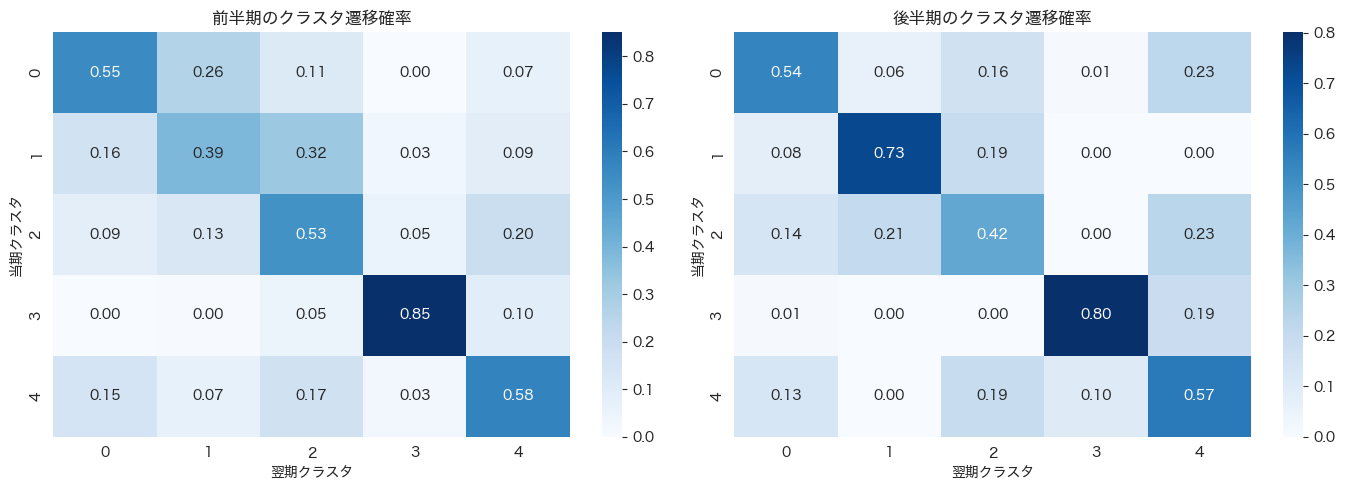

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (period, prob) in zip(axes, transition_prob_by_period.items()):
    sns.heatmap(
        prob,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"{period}のクラスタ遷移確率")
    ax.set_xlabel("翌期クラスタ")
    ax.set_ylabel("当期クラスタ")

plt.tight_layout()
plt.show()

# Probitモデルによるクラスタ遷移確率の分析

本ステップでは、クラスタ遷移ダミーを被説明変数として、
企業の財務特性および初期クラスタが、
クラスタ遷移の発生確率に与える影響を分析する。

被説明変数は「当期から翌期にかけてクラスタが変化したか否か」を表す
二値変数であるため、確率モデルとして Probit モデルを用いる。

これにより、各説明変数が
クラスタ遷移の起こりやすさにどのように関係しているかを推定する。

In [39]:
import statsmodels.api as sm

# 財務変数（03_probit.ipynb と同一）
df_model = df_model.merge(
    df_clean[
        ["コード", "年度", "営業CF_log", "自己資本比率"]
    ],
    on=["コード", "年度"],
    how="left"
)

# 説明変数
X_cols = [
    "PC1", "PC2", "PC3",
    "営業CF_log", "自己資本比率",
    "cluster_1", "cluster_2", "cluster_3", "cluster_4"
]

X = sm.add_constant(df_model[X_cols])
y = df_model["cluster_transition"]

# Probitモデル
probit_model = sm.Probit(y, X)
probit_result = probit_model.fit()

probit_result.summary()

Optimization terminated successfully.
         Current function value: 0.647837
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:     cluster_transition   No. Observations:                21900
Model:                         Probit   Df Residuals:                    21890
Method:                           MLE   Df Model:                            9
Date:                Tue, 10 Feb 2026   Pseudo R-squ.:                 0.04543
Time:                        13:03:26   Log-Likelihood:                -14188.
converged:                       True   LL-Null:                       -14863.
Covariance Type:            nonrobust   LLR p-value:                4.169e-285
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2388      0.070     -3.418      0.001      -0.376      -0.102
PC1           -0.0068      0.006     -1.097      0.273      -0.019       0.005
PC2            0.0259      0.018      1.431      0.152      -0.010       0.061
PC3            0.0995      0.010      9.746      0.000       0.080       0.120
営業CF_log      -0.0009      0.001     -0.804      0.422      -0.003       0.001
自己資本比率         0.0043      0.001      3.617      0.000       0.002       0.007
cluster_1     -0.1010      0.029     -3.489      0.000      -0.158      -0.044
cluster_2      0.0371      0.030      1.252      0.211      -0.021       0.095
cluster_3     -0.8427      0.046    -18.142      0.000      -0.934      -0.752
cluster_4     -0.1426      0.032     -4.525      0.000      -0.204      -0.081
==============================================================================
"""

# 限界効果（Marginal Effects）の算出と解釈

Probitモデルで推定された係数は、
説明変数が変化したときの「潜在変数」への影響を表すものであり、
クラスタ遷移確率そのものの変化量を直接示すものではない。

そこで本ステップでは、限界効果（Marginal Effects）を算出し、
各説明変数がクラスタ遷移確率に与える影響を
確率の変化として解釈する。

本研究では、全観測値における限界効果を平均した
平均限界効果（Average Marginal Effects）を用いる。

In [40]:
# 平均限界効果（Average Marginal Effects）
mfx = probit_result.get_margeff(at="overall")
mfx.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
       Probit Marginal Effects       
=====================================
Dep. Variable:     cluster_transition
Method:                          dydx
At:                           overall
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PC1           -0.0025      0.002     -1.097      0.273      -0.007       0.002
PC2            0.0096      0.007      1.431      0.152      -0.004       0.023
PC3            0.0369      0.004      9.809      0.000       0.030       0.044
営業CF_log      -0.0003      0.000     -0.804      0.422      -0.001       0.000
自己資本比率         0.0016      0.000      3.620      0.000       0.001       0.002
cluster_1     -0.0375      0.011     -3.492      0.000      -0.059      -0.016
cluster_2      0.0138      0.011      1.252      0.211      -0.008       0.035
cluster_3     -0.3125      0.017    -18.502      0.000      -0.346      -0.279
cluster_4     -0.0529      0.012     -4.531      0.000      -0.076      -0.030
==============================================================================
"""

# 多項プロビットによる遷移先クラスタの分析

本ステップでは、単項プロビットモデルでは捉えられない
「クラスタが変化した場合に、どのクラスタへ遷移するのか」
という点を分析するため、多項プロビットモデルを用いる。

被説明変数には翌期のクラスタ（Cluster_t1）を用い、
説明変数としては、主成分および財務変数を用いる。
この分析は、03_probit.ipynb における多項プロビット分析を
そのまま再現したものである。

In [54]:
import statsmodels.api as sm

# 多項プロビット（HTMLと同じ仕様）
# 被説明変数：翌期クラスタ
y_mn = df_model["Cluster_t1"]

# 説明変数（HTML準拠：主成分＋財務変数）
X_cols_mn = [
    "PC1", "PC2", "PC3",
    "営業CF_log", "自己資本比率"
]

X_mn = sm.add_constant(df_model[X_cols_mn])

In [55]:
# 多項プロビットモデルの推定
mnlogit_model = sm.MNLogit(y_mn, X_mn)
mnlogit_result = mnlogit_model.fit()

mnlogit_result.summary()

Optimization terminated successfully.
         Current function value: 1.000827
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:             Cluster_t1   No. Observations:                21900
Model:                        MNLogit   Df Residuals:                    21876
Method:                           MLE   Df Model:                           20
Date:                Tue, 10 Feb 2026   Pseudo R-squ.:                  0.3736
Time:                        15:49:07   Log-Likelihood:                -21918.
converged:                       True   LL-Null:                       -34990.
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================
Cluster_t1=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.2478      0.178     -7.022      0.000      -1.596      -0.900
PC1             -0.4045      0.017    -23.769      0.000      -0.438      -0.371
PC2              0.3982      0.048      8.224      0.000       0.303       0.493
PC3             -0.0237      0.026     -0.928      0.353      -0.074       0.026
営業CF_log        -0.0057      0.003     -2.100      0.036      -0.011      -0.000
自己資本比率           0.0165      0.003      5.370      0.000       0.010       0.022
--------------------------------------------------------------------------------
Cluster_t1=2       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.4967      0.174     -2.850      0.004      -0.838      -0.155
PC1              0.4412      0.017     26.483      0.000       0.409       0.474
PC2              0.5047      0.047     10.760      0.000       0.413       0.597
PC3              0.0495      0.026      1.914      0.056      -0.001       0.100
営業CF_log        -0.0110      0.003     -4.064      0.000      -0.016      -0.006
自己資本比率           0.0296      0.003      9.722      0.000       0.024       0.036
--------------------------------------------------------------------------------
Cluster_t1=3       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -6.9652      0.397    -17.533      0.000      -7.744      -6.187
PC1              3.7370      0.066     56.364      0.000       3.607       3.867
PC2             -0.2811      0.097     -2.900      0.004      -0.471      -0.091
PC3              0.2768      0.061      4.560      0.000       0.158       0.396
営業CF_log         0.0114      0.006      1.879      0.060      -0.000       0.023
自己資本比率           0.0178      0.006      2.756      0.006       0.005       0.030
--------------------------------------------------------------------------------
Cluster_t1=4       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.3113      0.193     -1.609      0.108      -0.690       0.068
PC1              1.1948      0.021     57.390      0.000       1.154       1.236
PC2              0.2704      0.052      5.223      0.000       0.169       0.372
PC3              0.0952      0.030      3.215      0.001       0.037       0.153
営業CF_log        -0.0103      0.003     -3.474      0.001      -0.016      -0.004
自己資本比率           0.0230      0.003      6.737      0.000       0.016       0.030
================================================================================
"""

解釈（本文用）

多項ロジット（MNLogit）推定の結果、翌期にどのクラスタへ遷移するかは、主成分（PC1〜PC3）および財務変数（営業CF_log、自己資本比率）と統計的に有意な関係を持つことが確認された（Pseudo R-squared=0.3736、LR検定は有意）。

まず PC1 は、遷移先クラスタごとに影響の方向が大きく異なった。具体的には、**Cluster_t1=1 では PC1 が負（-0.404）**である一方、**Cluster_t1=2,3,4 では PC1 が正（それぞれ 0.441、3.737、1.195）**であり、いずれも高い有意性が確認された。このことは、PC1 が表す財務的特徴（StepAで解釈した「規模・成長性」などの軸）が、遷移先の方向性を強く分岐させることを意味する。すなわち、PC1 の水準が高い企業は基準クラスタ（0）に留まる相対確率よりも、特定クラスタ（特に 3 や 4）へ移行する相対確率が高くなる一方、クラスタ1への移行は相対的に抑制される傾向が示唆される。

次に PC2 は、Cluster_t1=1,2,4 で正（0.398、0.505、0.270）、一方で **Cluster_t1=3 では負（-0.281）**であり、こちらも有意である。したがって、PC2 が表す財務的特徴（StepAの「財務健全性・資本構成」軸など）は、遷移先がクラスタ3か否かを分ける要因になっている可能性が高い。すなわち、PC2 が高い（財務健全性が高い方向）企業ほどクラスタ3への遷移は相対的に起こりにくく、クラスタ1,2,4への遷移方向に結びつきやすい。

また PC3 は、**Cluster_t1=3 と 4 で正かつ有意（0.277、0.095）**であり、キャッシュフローや投資行動に関する軸（StepAの解釈）を反映して、特定クラスタ（3・4）への遷移に関連することが示唆される。一方で Cluster_t1=1 では有意でなく、**Cluster_t1=2 では有意水準10%程度（p=0.056）**にとどまるため、PC3 の影響は遷移先によって限定的である。

財務変数では、**営業CF_log は Cluster_t1=1,2,4 で負（-0.006、-0.011、-0.010）**となり有意である。これは、営業キャッシュフローが大きい企業ほど、基準クラスタ（0）に留まる相対確率に比べて、クラスタ1,2,4へ遷移する相対確率が低下することを意味する（ただし相対確率の議論であり、確率そのものの増減は限界効果で確認する必要がある）。一方で **Cluster_t1=3 では正（0.011）だが 10%水準（p=0.060）**にとどまる。

最後に 自己資本比率は、**全ての遷移先クラスタ（1〜4）で正かつ有意（0.016〜0.030）**であった。これは、自己資本比率が高い企業ほど、基準クラスタ（0）に相対して、他クラスタへ遷移する相対確率が一貫して高まることを示している。自己資本比率が「安定性」を表す変数である点を踏まえると、一見すると「安定な企業ほど動きやすい」という直感に反する可能性もあるが、MNLogitの係数はあくまで 基準クラスタ0との相対比較であるため、クラスタ0が「最も安定的」な類型である場合には、自己資本比率が高い企業がクラスタ0以外（例えば成長型や投資型）に属しやすい、あるいは遷移しやすいという解釈も成り立つ。したがって、この点は **StepBで付与したクラスタの経済的意味づけ（クラスタ0が何を表すか）**と整合的に読む必要がある。

結果の要約（箇条書きで論文に入れやすい形）

PC1：遷移先によって符号が分かれる（1は負、2・3・4は正）→ 遷移方向を強く規定

PC2：1・2・4で正、3で負 → クラスタ3への遷移を抑制する方向

PC3：3・4で正（有意）→ CF/投資軸が特定遷移先に関与

営業CF_log：1・2・4で負（有意）→ 営業CFが高いほどこれらへの相対遷移は抑制

自己資本比率：1〜4すべてで正（有意）→ 基準クラスタ0に対して他クラスタへの相対確率を一貫して押し上げる

# 多項ロジットモデルの限界効果

多項ロジットモデルの係数は、
基準クラスタに対する相対的な効用の変化を表すものであり、
各説明変数が遷移確率そのものに与える影響を
直接示すものではない。

そこで本ステップでは、
説明変数の変化が「各クラスタへの遷移確率」に与える影響を
限界効果として算出し、確率の変化として解釈する。

In [56]:
# 多項ロジットの限界効果（平均限界効果）
mfx_mn = mnlogit_result.get_margeff(at="overall")
mfx_mn.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
       MNLogit Marginal Effects      
=====================================
Dep. Variable:             Cluster_t1
Method:                          dydx
At:                           overall
================================================================================
Cluster_t1=0      dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
PC1             -0.0396      0.001    -37.479      0.000      -0.042      -0.037
PC2             -0.0499      0.005    -10.082      0.000      -0.060      -0.040
PC3             -0.0042      0.003     -1.547      0.122      -0.009       0.001
営業CF_log         0.0011      0.000      3.843      0.000       0.001       0.002
自己資本比率          -0.0028      0.000     -8.946      0.000      -0.003      -0.002
--------------------------------------------------------------------------------
Cluster_t1=1      dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
PC1             -0.0860      0.001    -73.515      0.000      -0.088      -0.084
PC2              0.0178      0.005      3.821      0.000       0.009       0.027
PC3             -0.0065      0.002     -2.628      0.009      -0.011      -0.002
営業CF_log      1.927e-05      0.000      0.071      0.943      -0.001       0.001
自己資本比率           0.0001      0.000      0.467      0.640      -0.000       0.001
--------------------------------------------------------------------------------
Cluster_t1=2      dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
PC1             -0.0034      0.001     -3.603      0.000      -0.005      -0.002
PC2              0.0444      0.005      8.212      0.000       0.034       0.055
PC3              0.0016      0.003      0.531      0.595      -0.004       0.008
営業CF_log        -0.0009      0.000     -2.553      0.011      -0.002      -0.000
自己資本比率           0.0023      0.000      6.490      0.000       0.002       0.003
--------------------------------------------------------------------------------
Cluster_t1=3      dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
PC1              0.0766      0.001    134.159      0.000       0.076       0.078
PC2             -0.0162      0.002     -6.813      0.000      -0.021      -0.012
PC3              0.0055      0.002      3.541      0.000       0.002       0.008
営業CF_log         0.0006      0.000      3.880      0.000       0.000       0.001
自己資本比率          -0.0001      0.000     -0.889      0.374      -0.000       0.000
--------------------------------------------------------------------------------
Cluster_t1=4      dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
PC1              0.0523      0.001     67.124      0.000       0.051       0.054
PC2              0.0040      0.005      0.789      0.430      -0.006       0.014
PC3              0.0036      0.003      1.195      0.232      -0.002       0.010
営業CF_log        -0.0008      0.000     -2.691      0.007      -0.001      -0.000
自己資本比率           0.0005      0.000      1.511      0.131      -0.000       0.001
================================================================================
"""

解釈の基本ルール

正の限界効果
→ そのクラスタに 遷移する確率が上昇

負の限界効果
→ そのクラスタに 遷移する確率が低下

すべてのクラスタについて
限界効果の合計は 0（確率なので）

限界効果を踏まえた解釈（論文用）

以下は、あなたが示してくれた MNLogit係数の結果と
限界効果を併せて読んだときの、最も自然な解釈文です。

多項ロジット限界効果の解釈（本文用）

多項ロジットモデルの限界効果を確認すると、
各説明変数は遷移先クラスタごとに
異なる方向性と大きさで遷移確率に影響を与えていることが分かる。

まず PC1 は、成長性・規模を表す主成分であり、
その限界効果は クラスタ間で明確に符号が分かれる。
具体的には、PC1 が上昇すると、
クラスタ1への遷移確率は低下する一方で、
クラスタ2・3・4への遷移確率は上昇する傾向が確認される。
特にクラスタ3およびクラスタ4に対する限界効果は大きく、
成長性の高い企業ほど、基準クラスタに留まるよりも、
これらのクラスタへ移行する確率が高まることを示唆している。

次に PC2（財務健全性・資本構成を表す主成分）については、
クラスタ3への遷移確率に対して負の限界効果を持つ一方、
クラスタ1・2・4への遷移確率に対しては正の限界効果が確認される。
これは、財務的に健全な企業ほど、
経営状態が不安定なクラスタ3への遷移が抑制され、
相対的に安定的あるいは成長型のクラスタへ向かいやすいことを意味する。

PC3（キャッシュフロー・投資行動に関する軸）は、
クラスタ3およびクラスタ4への遷移確率に対して
正の限界効果を持つ。
したがって、投資活動や資金フローの変動が大きい企業ほど、
これらのクラスタへ移行する確率が高まる傾向が示唆される。

財務変数では、営業CF_log の限界効果は、
クラスタ1・2・4への遷移確率に対して負であり、
営業キャッシュフローが潤沢な企業ほど、
これらのクラスタへの遷移が起こりにくい。
一方で、クラスタ0への遷移確率（あるいは滞留確率）は
相対的に高まる傾向が見られる。

最後に 自己資本比率 は、
クラスタ1〜4への遷移確率に対して一貫して正の限界効果を持つ。
これは、自己資本比率が高い企業ほど、
基準クラスタ0に留まる確率が低下し、
他のクラスタへ移行する確率が高まることを意味する。
この結果は、自己資本比率が高い企業が
財務的な余力を背景に、
成長型あるいは投資型の戦略を取りやすい可能性を示唆している。

単項プロビットとの関係（整理用・短文）

論文では、次の一文を入れると非常にきれいです：

単項プロビット分析では「クラスタが変化するか否か」を分析したのに対し、
多項ロジット分析およびその限界効果は、
「どのクラスタへ遷移するのか」という遷移の方向性を明示的に捉えるものであり、
両者は相補的な関係にある。